# Simulações para expansão térmica

- Tô em dúvida quanto ao tempo de termalização.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('../mestrado.mplstyle')

## Como extrair a tabela thermo_style do LAMMPS

### Modo 1
```bash
cat log.lammps | sed -n "/Step/,/Loop time/p" | head -n-1 > thermo.out   
```

Detalhes da execução:

- `sed -n "/Step/,/Loop time/p"`:
    - Imprime todas as linhas que começam com "Step" e vão até a linha que contém "Loop time", que marca o fim do bloco de termodinâmica. 
- `head -n-1:`
    - Remove a última linha do resultado, que é a linha "Loop time", deixando apenas os dados das variáveis termodinâmicas. 

Se tiver duas runs, tem que pegar a separação das tabelas e excluir. 


### Modo 2
Adicione ao `~.bashrc`

~~~bash
function extract_thermo(){
    # extract the thermo data from a LAMMPS log file and save it to a .dat file
    # usage: extract_thermo log.lammps thermo.dat
    if [ $# -ne 2 ]; then
        echo "Usage: extract_thermo log.lammps thermo.dat"
        return 1
    fi  
    log_file=$1
    output_file=$2
    awk '/Step/{flag=1; next} /Loop/{flag=0} flag' $log_file > $output_file

}

~~~


In [3]:
header = 'Step Temp Press Volume KinEng PotEng TotEng'.split(" ")
thermo = "./100K/logs/thermo.dat"
df = pd.DataFrame(np.loadtxt(thermo), columns=header)

display(df)


,Step,Temp,Press,Volume,KinEng,PotEng,TotEng
0,0.0,100.000000,-157635.790000,2905.4508,3.296134,-784912.13,-784908.83
1,100.0,111.141940,-22242.354000,2617.7376,3.663387,-784925.42,-784921.76
2,200.0,129.165360,8457.806900,2568.5297,4.257463,-784926.24,-784921.98
3,300.0,110.497590,7716.360800,2578.5768,3.642148,-784926.73,-784923.08
4,400.0,106.445440,7607.618200,2581.5172,3.508584,-784926.75,-784923.24
5,500.0,123.764480,4406.717200,2554.5818,4.079443,-784927.69,-784923.61
6,600.0,512.944630,5796.418800,2421.5421,16.907341,-784947.12,-784930.22
7,700.0,802.424780,-10485.902000,2399.7919,26.448993,-784988.82,-784962.37
8,800.0,1122.404000,9525.160500,2312.3168,36.995938,-785069.32,-785032.33
9,900.0,1000.859500,-13306.331000,2454.4196,32.989666,-785164.41,-785131.42


In [4]:
def plot_thermo(thermodat: str, **kwargs) -> None:
    header = 'Step Temp Press Volume KinEng PotEng TotEng'.split(" ")
    df = pd.DataFrame(np.loadtxt(thermodat), columns=header)
    fig, (ax_E, ax_V, ax_P) = plt.subplots(ncols=3, figsize=(18,5), layout='constrained', dpi=300)
    
    if kwargs.get("figtitle"):
        fig.suptitle(kwargs["figtitle"])

    ax_titles = ["Energy", "Volume", "Pressure"]


    df.plot(x='Step', y="TotEng", ax=ax_E, rot=45, color="darkred")
    df.plot(x='Step', y="Volume", ax=ax_V, rot=45, color="darkgreen")
    df.plot(x='Step', y="Press", ax=ax_P, rot=45, color="darkblue")

    for i, ax in enumerate((ax_E, ax_V, ax_P)):
        ax.set_title(ax_titles[i])
        ax.set_xlabel(r"MD Step ($10^3$)")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}'))



    ax_E.axhline(df["TotEng"].mean(), color='orange', lw=2, ls="--", label=r"$\langle E \rangle$")
    ax_P.axhline(df.Press.mean(), color='orange', lw=2, ls="--", label=r"$\langle P \rangle$")
    ax_V.axhline(df.Volume.mean(), color='orange', lw=2, ls="--", label=r"$\langle V \rangle$")

    ax_E.legend()
    ax_P.legend()
    ax_V.legend()


    plt.show()



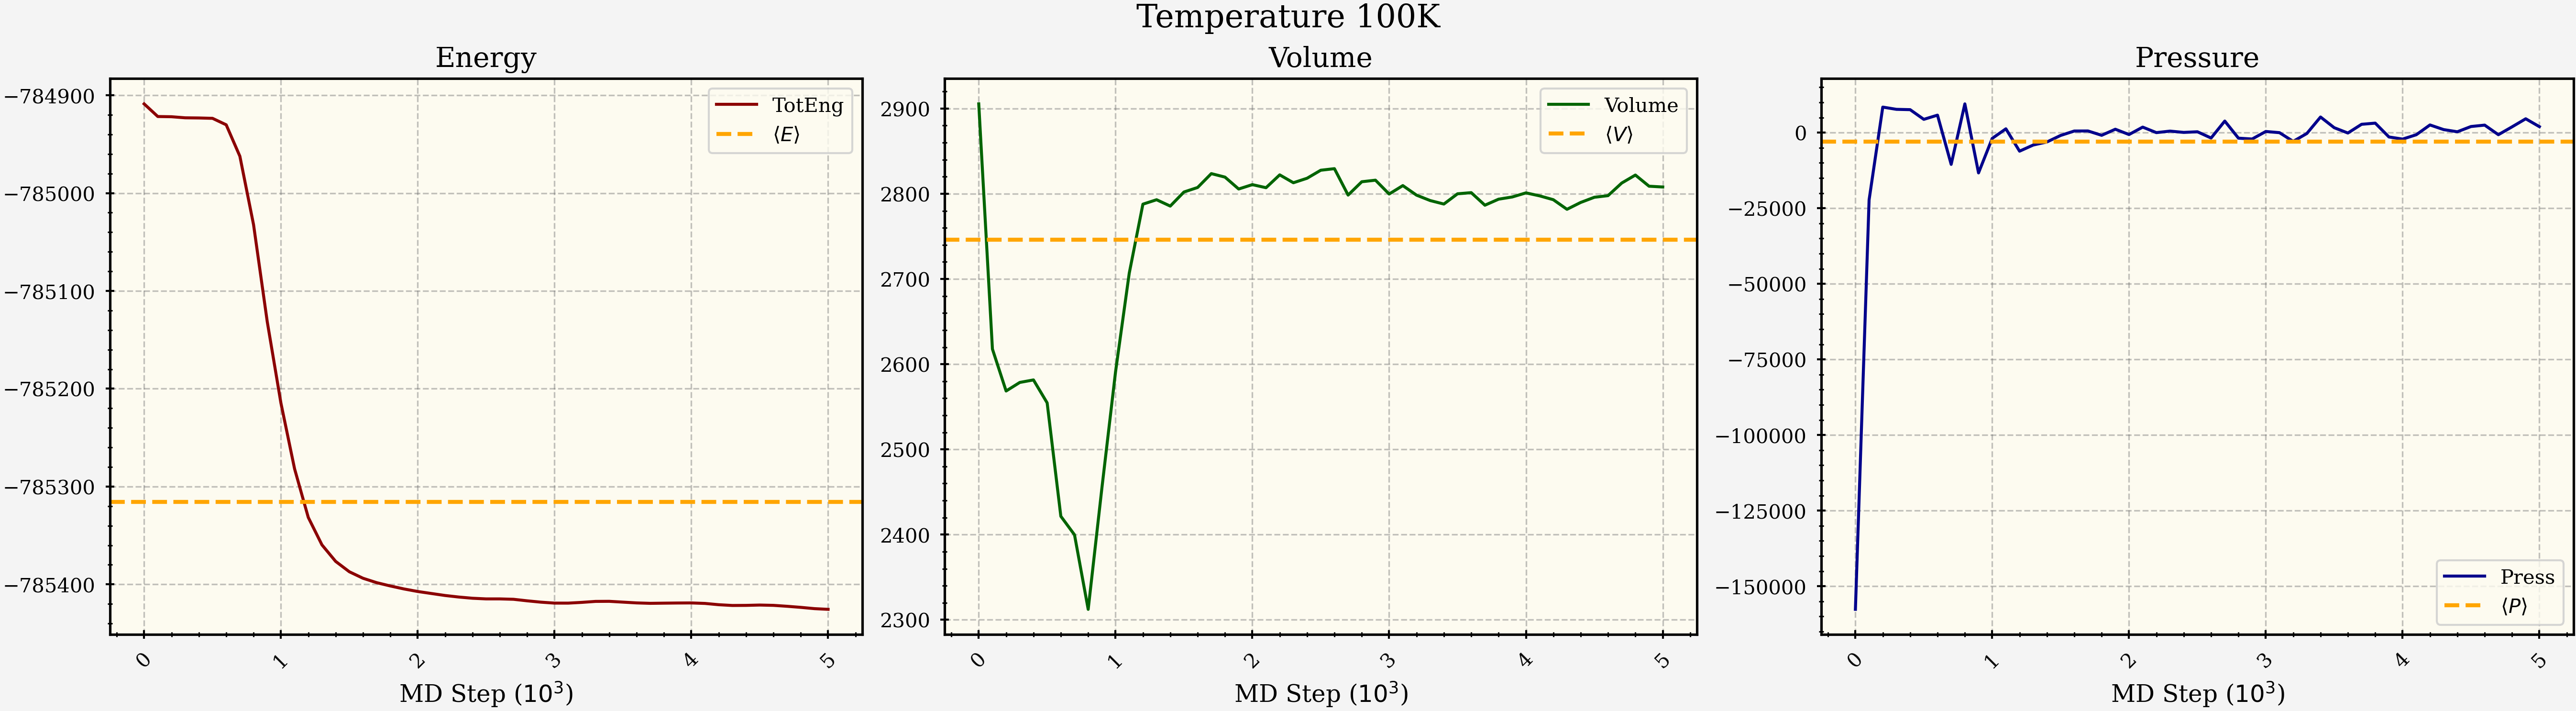

In [5]:
fig, (ax_E, ax_V, ax_P) = plt.subplots(ncols=3, figsize=(18,5), layout='constrained', dpi=300)
fig.suptitle("Temperature 100K")

ax_titles = ["Energy", "Volume", "Pressure"]


df.plot(x='Step', y="TotEng", ax=ax_E, rot=45, color="darkred")
df.plot(x='Step', y="Volume", ax=ax_V, rot=45, color="darkgreen")
df.plot(x='Step', y="Press", ax=ax_P, rot=45, color="darkblue")

for i, ax in enumerate((ax_E, ax_V, ax_P)):
    ax.set_title(ax_titles[i])
    ax.set_xlabel(r"MD Step ($10^3$)")

for ax in (ax_E, ax_V, ax_P):
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}'))


ax_E.axhline(df["TotEng"].mean(), color='orange', lw=2, ls="--", label=r"$\langle E \rangle$")
ax_P.axhline(df.Press.mean(), color='orange', lw=2, ls="--", label=r"$\langle P \rangle$")
ax_V.axhline(df.Volume.mean(), color='orange', lw=2, ls="--", label=r"$\langle V \rangle$")

ax_E.legend()
ax_P.legend()
ax_V.legend()

plt.show()

Filtrando pelos passos de produção.

In [ ]:

nequil = 200000
nprod = 300000
prod = df.query(f"{nequil} <= Step <= {nprod}")

display(prod)
plot_thermo("./100K/tabela.dat", figtitle="Temperature 100K")
mean_volume = prod["Volume"].mean() / (256 / 2)
print(f"Volume médio T = 100K : {mean_volume:.6f}")
volumes = prod["Volume"].to_numpy()

media = volumes.mean()
desvio = volumes.std()
quantidade = volumes.size


# --- Plot
fig, ax = plt.subplots(figsize=(6,5), dpi=300)
fig.suptitle("Histograma de Volumes\nFase de Produção: 200 à 300k MD steps", size=16)
ax.set_title("Distribuição normal",loc='left')

ax.hist(volumes, bins=30, density=True, alpha=0.6, color='b')

# Normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = (1 / (desvio * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - media) / desvio)**2)

ax.plot(x, p, "k-", lw=2)

plt.show()


,Step,Temp,Press,Volume,KinEng,PotEng,TotEng
200,200000.0,109.007510,-929.61181,4626.4142,3.593033,-785537.27,-785533.68
201,200000.0,109.007510,-929.61181,4626.4142,3.593033,-785537.27,-785533.68
202,201000.0,104.006500,-1811.99080,4601.7472,3.428193,-785537.30,-785533.87
203,202000.0,97.273116,793.06516,4634.8873,3.206252,-785537.53,-785534.33
204,203000.0,102.558700,1247.53150,4579.5447,3.380472,-785537.27,-785533.89
...,...,...,...,...,...,...,...
297,296000.0,95.930600,-1142.73200,4553.5111,3.162001,-785541.40,-785538.24
298,297000.0,98.770796,-1097.74520,4587.4051,3.255618,-785541.12,-785537.87
299,298000.0,105.508900,3067.34850,4504.0538,3.477714,-785541.06,-785537.59
300,299000.0,101.950530,-971.33698,4563.1612,3.360426,-785541.16,-785537.80


In [6]:
from ase.io import read

In [23]:
atoms = read("./100K/trajectories/trajectory_100K.lammpstrj", index=":") 

In [25]:
atoms[0]

Atoms(symbols='H128He128', pbc=True, cell=[[12.784713245782523, 0.0, 0.0], [-6.3923566228912625, 11.071886453293255, 0.0], [0.0, 0.0, 20.525838843873927]], momenta=..., type=...)